# FOV Finder Agent — standalone demo

Uses `FOVFinderAgent` on its own (no BO, no composition) to:

1. Load a plate calibration (`WellPlatePlan`) saved by the **MDA plate widget** of `pymmcore-widgets`.
2. For an ordered list of wells, generate random candidate positions inside each well — kept `border_um` away from the well edge.
3. Image each candidate via `mic.run_mda` with the user's imaging channels.
4. Segment each frame with the user's `Segmentator` and count cells.
5. Filter out positions with `< min_cells` cells, then pick `fovs_per_well` per well via **farthest-point sampling** so they don't overlap.

This notebook is the simplest possible usage. See `fov_finder_cnr_demo.ipynb` for the extended variant that also filters FOVs by per-cell features (e.g. CNR) via `FOVCondition`. See `experiments/31_bo_optimisation/bo_erk_oscillation.ipynb` for the FOV finder coupled to a BO inter-phase agent via `ComposedAgent`.

## 1. Microscope and channel setup

In [1]:
from faro.microscope.pertzlab.jungfrau import Jungfrau
from faro.core.data_structures import PowerChannel

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")

# Channels used to scan candidate positions. Stim/ref channels are intentionally
# *not* used here — the FOV finder only acquires imaging channels.
imaging_channels = (
    PowerChannel(config="miRFP", exposure=125, group="TTL_ERK", power=95),
    PowerChannel(config="mScarlet3", exposure=125, group="TTL_ERK", power=95),
)

In [2]:
mic.mmc.setProperty(
    "TIPFSStatus", "State", "On"
)  # Focus had already been done, so turn on the PFS,
# if not done, do it through napari-micromanager GUI, execute lines below

# from napari_micromanager import MainWindow
# import napari

# viewer = napari.Viewer()
# mm_wdg = MainWindow(viewer)
# mm_wdg._mmc = mic.mmc  # point the widget at our CMMCore instance
# viewer.window.add_dock_widget(mm_wdg)  # dock Micro-Manager controls in napari

## 2. Plate calibration

Calibrate the plate once using the `pymmcore-widgets` MDA plate widget (it stores the affine transformation as `a1_center_xy` + `rotation` in a `useq.WellPlatePlan` JSON file). Point this notebook at that file.

In [3]:
PLATE_CALIBRATION_PATH = "./calib_plate_96.json"
# Quick sanity check
from useq import WellPlatePlan

plan = WellPlatePlan.from_file(PLATE_CALIBRATION_PATH)
print(f"plate: {plan.plate.name}  rows={plan.plate.rows}  cols={plan.plate.columns}")
print(f"well_size mm: {plan.plate.well_size}  circular: {plan.plate.circular_wells}")
print(f"a1_center_xy: {plan.a1_center_xy}  rotation: {plan.rotation}")

plate: 96-well  rows=8  cols=12
well_size mm: (6.4, 6.4)  circular: True
a1_center_xy: (54831.5615, -32014.7363)  rotation: -179.87


## 3. Segmentator

Use whichever segmentator gives a sensible cell count from the channel you want to score (here we segment the first imaging channel — the nuclear marker).

In [4]:
from faro.segmentation.cellpose_v4 import CellposeV4

segmentator = CellposeV4()

## 4. Configure the FOV finder

Key knobs:

- `wells` — ordered list of wells (e.g. `["B2", "B3", "B4", ...]`).
- `wells_per_phase` — how many wells one `run()` call consumes.
- `fovs_per_well` — how many positions per well are returned.
- `n_candidates_per_well` — how many random candidates are scanned per well; should be larger than `fovs_per_well` so the farthest-point sampler has room to spread the picks.
- `border_um` — minimum distance to keep candidates away from the well edge.
- `min_cells` / `max_cells` — cell-count bounds for a candidate to be considered valid.
- `seg_channel_index` — which imaging channel to segment (default `0`).
- `feature_extractor` — optional; if supplied, `extract_positions({"labels": label_image})` is called per FOV and the results are attached to `all_candidates` (purely informational, does not influence selection). To filter FOVs by per-cell features, see `fov_finder_cnr_demo.ipynb`.

In [5]:
from faro.agents import FOVFinderAgent

wells = ["B2", "B3", "B4"]

finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=wells,
    # wells_per_phase omitted -> consumes the entire queue in one run()
    fovs_per_well=3,
    n_candidates_per_well=6,
    border_um=1500.0,  # keep candidates 1.5 mm from the well edge
    min_distance_um=1000.0,  # spread candidates ~1 mm apart in the random scan
    min_cells=30,  # need >=30 cells in the seg channel
    max_cells=None,  # no upper bound on cell count
    imaging_channels=[
        PowerChannel(config="miRFP", exposure=125, group="TTL_ERK", power=95),
    ],
    segmentator=segmentator,
    seg_channel_index=0,  # segment on miRFP (nuclear marker)
    z=None,  # leave Z untouched (PFS holds focus)
    random_seed=42,
    verbose=True,  # show per-candidate + per-well debug plots
)

print(f"Wells queued: {len(finder.remaining_wells)}")
print(f"Phases this queue can drive: {finder.n_remaining_phases}")

Wells queued: 3
Phases this queue can drive: 1


[FOVFinderAgent] Phase 0: scanning 6 candidates in 3 wells: ['B2', 'B3', 'B4']


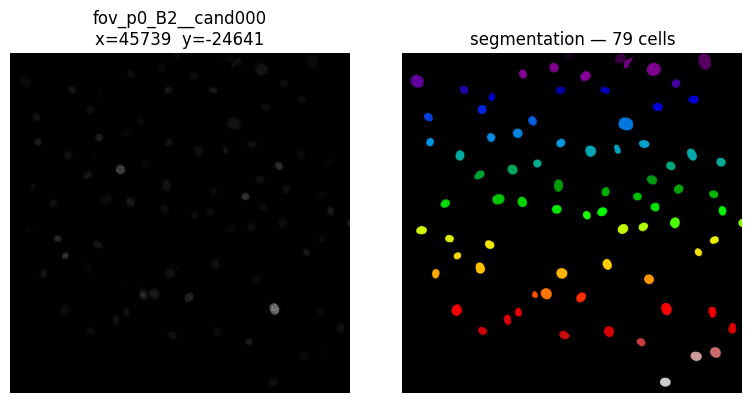

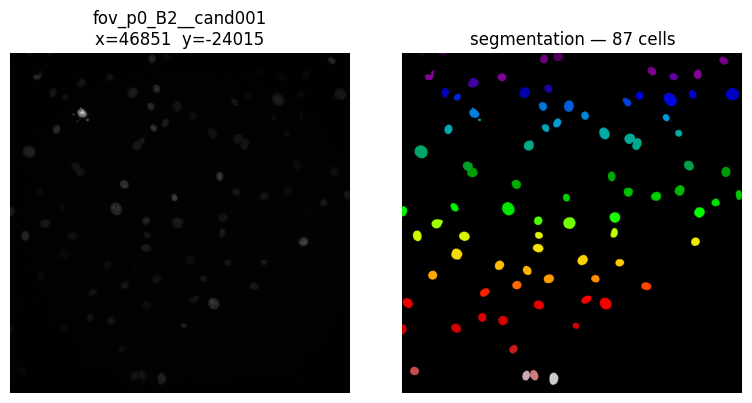

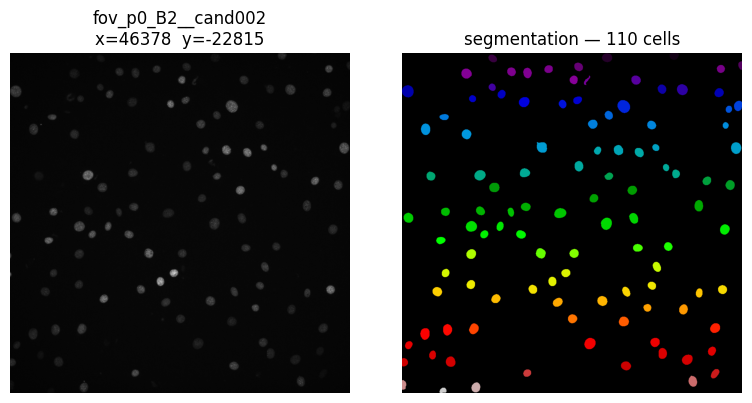

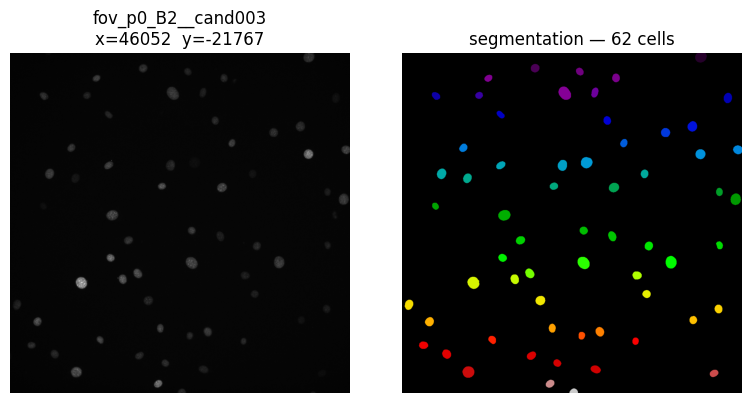

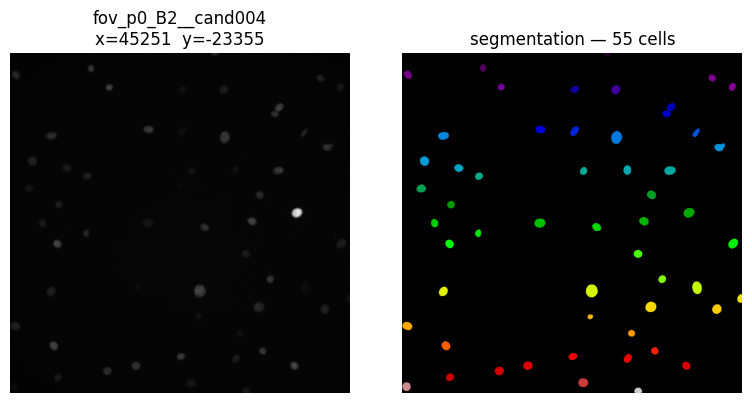

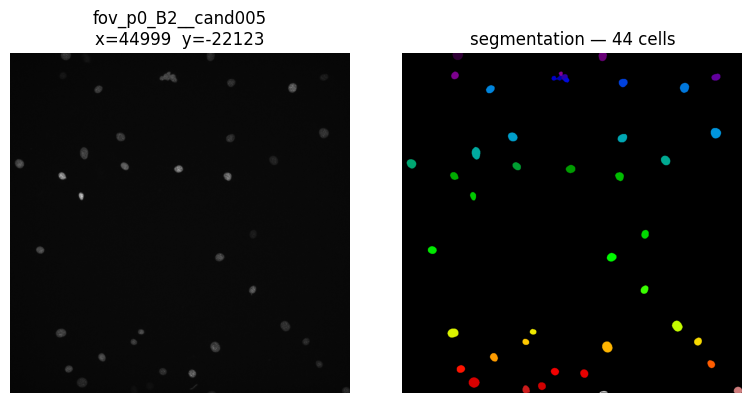

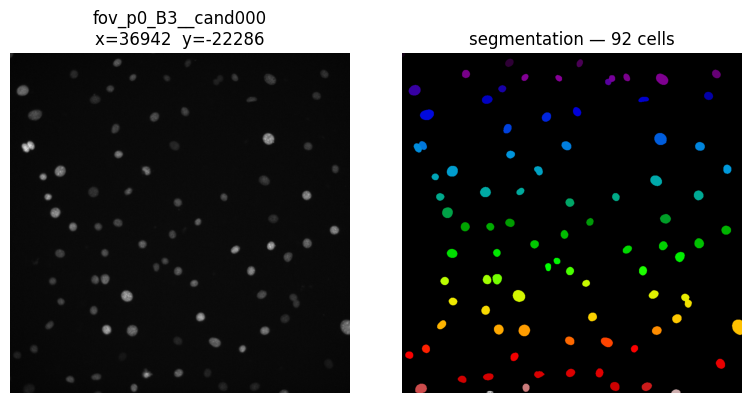

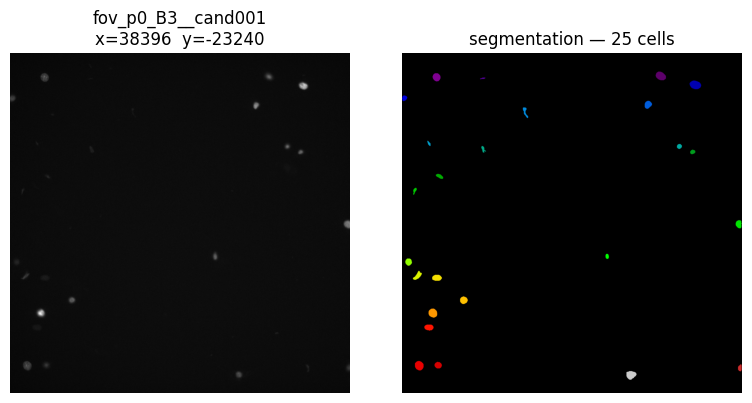

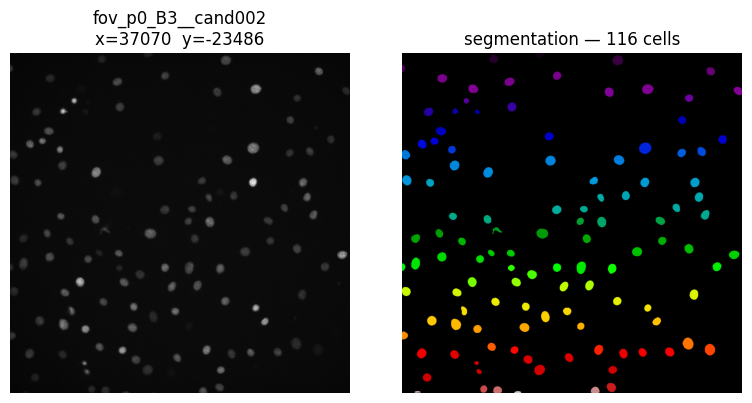

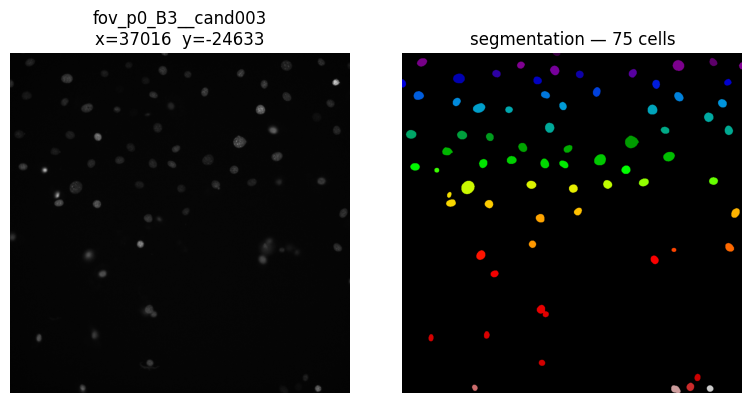

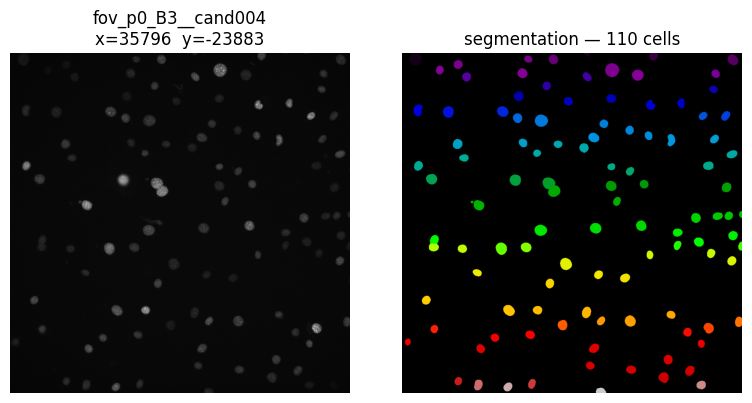

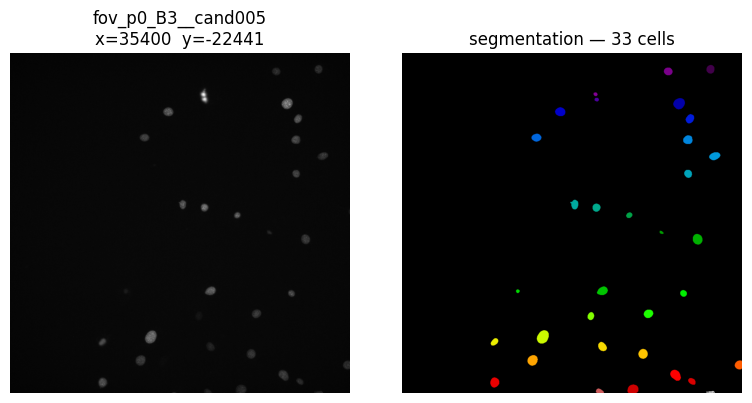

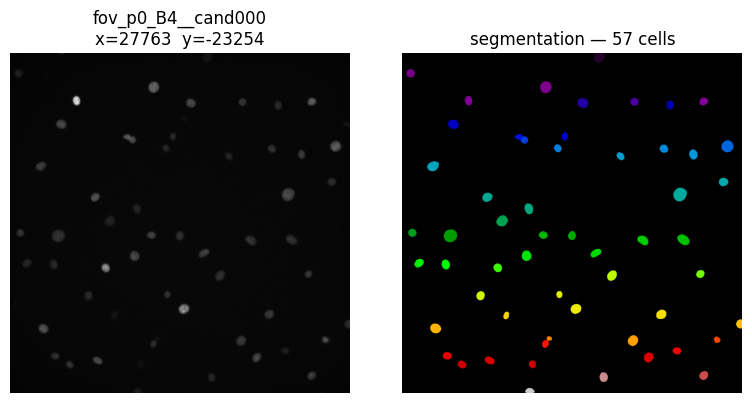

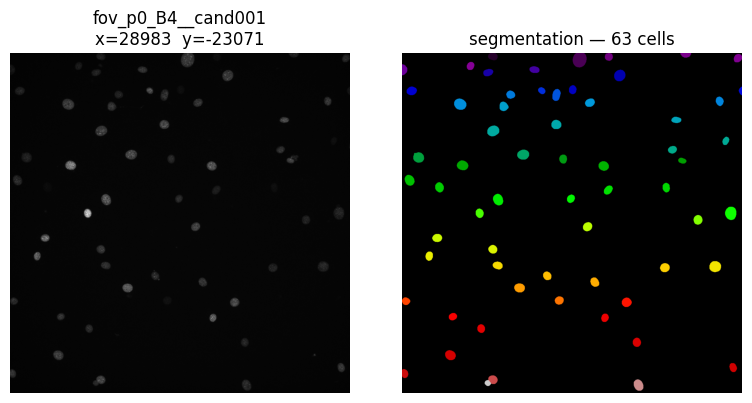

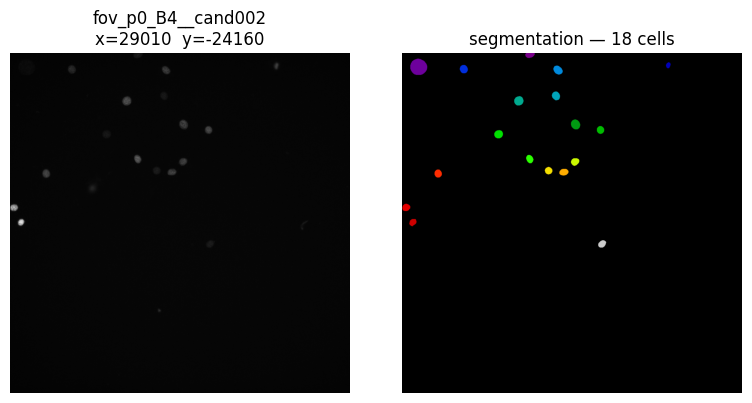

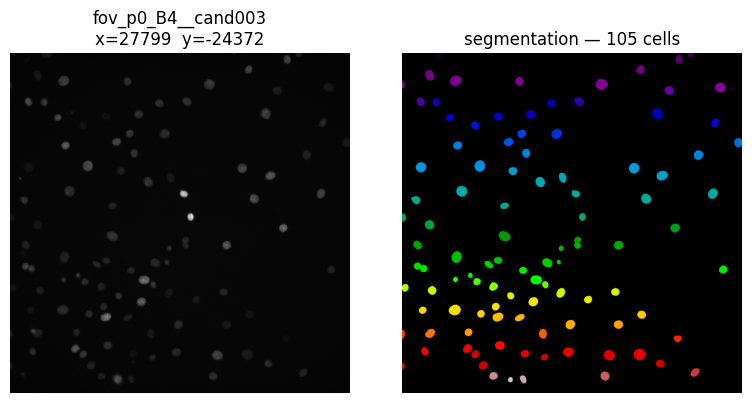

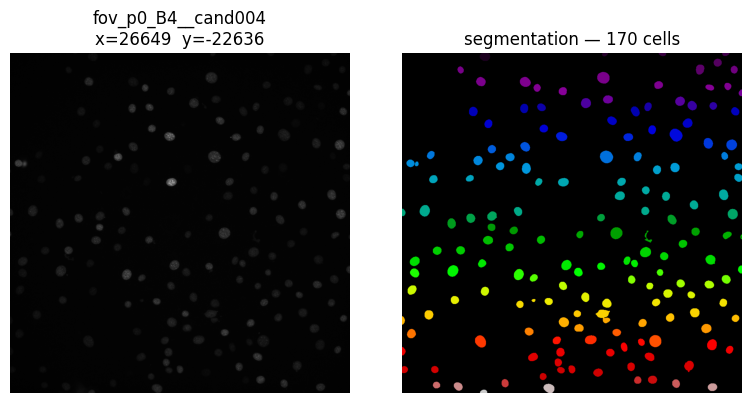

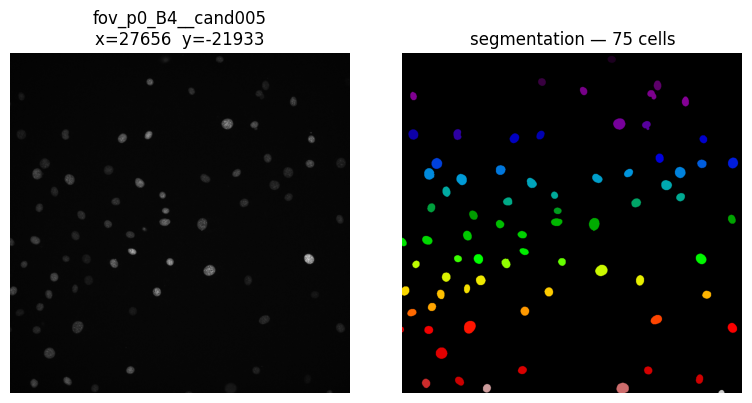

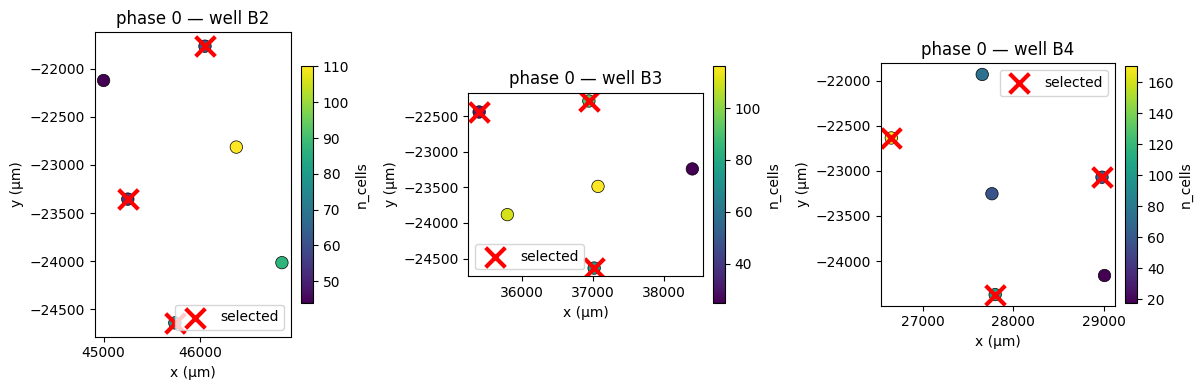

[FOVFinderAgent] Phase 0: selected 9 FOVs across 3 wells (median valid candidates/well: 5).


In [6]:
selected = finder.run()  # list[FovPosition]

In [7]:
selected

[FovPosition(x=45739.28253534232, y=-24641.0616861673, z=None, name='B2_0000'),
 FovPosition(x=46052.26194809588, y=-21766.558498222887, z=None, name='B2_0001'),
 FovPosition(x=45250.85889012353, y=-23355.181402976385, z=None, name='B2_0002'),
 FovPosition(x=37015.75956664451, y=-24633.441807276915, z=None, name='B3_0000'),
 FovPosition(x=35399.88896446866, y=-22440.545928703184, z=None, name='B3_0001'),
 FovPosition(x=36942.01195962964, y=-22285.887409883908, z=None, name='B3_0002'),
 FovPosition(x=26648.524103851894, y=-22636.45257605735, z=None, name='B4_0000'),
 FovPosition(x=28982.793150594345, y=-23071.07606235565, z=None, name='B4_0001'),
 FovPosition(x=27799.063443011226, y=-24371.602445795215, z=None, name='B4_0002')]

## 5. (Optional) drive multiple phases

Each call to `run()` consumes the next `wells_per_phase` wells from the queue. You can call `run()` repeatedly to step through batches of wells.

In [ ]:
# Example: another finder with smaller batches so we can run multiple phases
finder2 = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=["C2", "C3", "C4", "C5"],
    wells_per_phase=2,
    fovs_per_well=3,
    n_candidates_per_well=6,
    border_um=1500.0,  # keep candidates 1.5 mm from the well edge
    min_distance_um=1000.0,  # spread candidates ~1 mm apart in the random scan
    min_cells=30,  # need >=30 cells in the seg channel
    max_cells=None,  # no upper bound on cell count
    imaging_channels=[
        PowerChannel(config="miRFP", exposure=125, group="TTL_ERK", power=95),
    ],
    segmentator=segmentator,
    seg_channel_index=0,  # segment on miRFP (nuclear marker)
    z=None,  # leave Z untouched (PFS holds focus)
    random_seed=8,
    verbose=True,  # show per-candidate + per-well debug plots
)

finder2.run()  # runs on C2+C3


# all_phases = []
# while finder2.remaining_wells:
#     res = finder2.run()
#     all_phases.append(res)
#     print(
#         f"phase {res['phase']}: {len(res['positions'])} FOVs from wells {res['wells_used']}"
#     )

# print(f"\nTotal phases run: {len(all_phases)}")

In [ ]:
finder2.remaining_wells  # should be ['C4', 'C5'] since we set wells_per_phase=2

In [ ]:
finder2.run()  # runs on C4+C5